In [37]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import random
import statsmodels.api as sm
import statsmodels.stats.diagnostic as smd
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats
import statsmodels.stats.diagnostic as diag
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

from sklearn.compose import make_column_selector as selector #Para seleccionar de forma automática las variables numéricas y categóricas
from sklearn.preprocessing import OneHotEncoder #Para codificar las variables categóricas usando dummies
from sklearn.preprocessing import StandardScaler #Para normalizar las variables numéricas
from sklearn.compose import ColumnTransformer #Modifica las columnas usando los preprocesadores
from sklearn.pipeline import make_pipeline #Planifica una secuencia de procesos
from sklearn import set_config #Para mostrar graficamente el pipeline
from sklearn.model_selection import GridSearchCV

set_config(display='diagram')
#Metrics
from sklearn.metrics import make_scorer, accuracy_score,precision_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score ,precision_score,recall_score,f1_score

In [38]:
# Cargar el archivo
df = pd.read_csv('violencia_unite_data.csv')

# Convertir 'CONDUCENTE' a binario: 1.0 -> 1, 2.0 o 9.0 -> 0
df['CONDUCENTE'] = df['CONDUCENTE'].replace({2.0: 0, 9.0: 0})

# Eliminar filas con valores nulos en la variable objetivo
df = df.dropna(subset=['CONDUCENTE'])

#submuestreo

#separar por clase
df_1 = df[df['CONDUCENTE'] == 1]
df_0 = df[df['CONDUCENTE'] == 0]

# Submuestreo de la clase mayoritaria (1.0)
df_1_downsampled = df_1.sample(len(df_0), random_state=42)

# Unir los conjuntos balanceados
df = pd.concat([df_1_downsampled, df_0])

# Mezclar el dataframe
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

df.value_counts('CONDUCENTE')

CONDUCENTE
0.0    8038
1.0    8038
Name: count, dtype: int64

In [39]:
# Variable objetivo
y = df['CONDUCENTE']

# Selección de características
X = df[[
    'REP_DEP', 'REP_MUNI', 'VIC_SEXO', 'VIC_EDAD',
    'AGR_SEXO', 'AGR_EDAD', 'VIC_GRUPET', 'AGR_GRUPET',
    'VIC_NACIONAL', 'AGR_NACIONAL', 'VIC_OCUP', 'AGR_OCUP',
    'HEC_DEP', 'HEC_MUNI', 'HEC_AREA'
]]
# Separar columnas categóricas y numéricas
categorical_cols = X.select_dtypes(include='object').columns.tolist()
numerical_cols = X.select_dtypes(exclude='object').columns.tolist()

# Crear transformador de columnas
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'  # Deja pasar columnas numéricas tal cual
)

In [40]:
from sklearn.preprocessing import StandardScaler

# Transformador para características numéricas
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numerical_cols)  # Normalización de columnas numéricas
    ],
    remainder='passthrough'
)

In [41]:
from sklearn.model_selection import train_test_split

# Dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [42]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12860 entries, 1057 to 7270
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   REP_DEP       12860 non-null  object
 1   REP_MUNI      12860 non-null  object
 2   VIC_SEXO      12860 non-null  object
 3   VIC_EDAD      12860 non-null  int64 
 4   AGR_SEXO      12860 non-null  object
 5   AGR_EDAD      12860 non-null  int64 
 6   VIC_GRUPET    12860 non-null  object
 7   AGR_GRUPET    12860 non-null  object
 8   VIC_NACIONAL  12860 non-null  object
 9   AGR_NACIONAL  12860 non-null  object
 10  VIC_OCUP      4829 non-null   object
 11  AGR_OCUP      11336 non-null  object
 12  HEC_DEP       12860 non-null  object
 13  HEC_MUNI      12860 non-null  object
 14  HEC_AREA      12860 non-null  object
dtypes: int64(2), object(13)
memory usage: 1.6+ MB


In [43]:
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline

# Crear un pipeline con el preprocesamiento y el clasificador
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', MLPClassifier(hidden_layer_sizes=(50, 30), max_iter=1000, random_state=42))
])

# Entrenar el modelo
model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['REP_DEP', 'REP_MUNI',
                                                   'VIC_SEXO', 'AGR_SEXO',
                                                   'VIC_GRUPET', 'AGR_GRUPET',
                                                   'VIC_NACIONAL',
                                                   'AGR_NACIONAL', 'VIC_OCUP',
                                                   'AGR_OCUP', 'HEC_DEP',
                                                   'HEC_MUNI', 'HEC_AREA']),
                                                 ('num', StandardScaler(),
                                                  ['VIC_EDAD', 'AGR_EDAD'])])),
                ('classifier',
                 MLPClassifier(hidden_layer_sizes=(50, 30), max_iter=1000,
                               random_state=42))])

In [44]:
y_pred = model.predict(X_test)
y_pred

array([1., 0., 1., ..., 1., 1., 1.])

Matriz de confusión
 [[ 936  642]
 [ 621 1017]]
Accuracy:  0.6072761194029851
Precision:  0.6072761194029851
recall:  0.6072761194029851
f1score:  0.6072761194029851


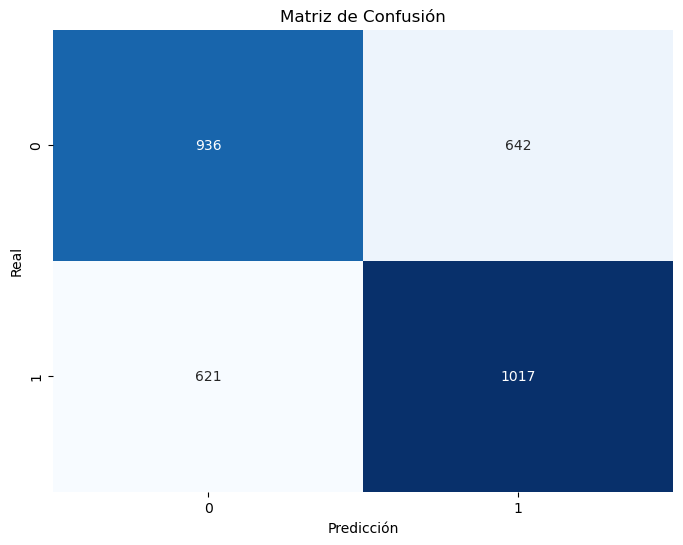

In [45]:
cm = confusion_matrix(y_test,y_pred)
accuracy=accuracy_score(y_test,y_pred)
precision =precision_score(y_test, y_pred,average='micro')
recall =  recall_score(y_test, y_pred,average='micro')
f1 = f1_score(y_test,y_pred,average='micro')
print('Matriz de confusión\n',cm)
print('Accuracy: ',accuracy)
print('Precision: ', precision)
print('recall: ',recall)
print('f1score: ',f1)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=True, yticklabels=True)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()

In [46]:
# Crear un pipeline con el preprocesamiento y el clasificador
model2 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', MLPClassifier(hidden_layer_sizes=(100, ), max_iter=1000, random_state=42, learning_rate='adaptive'))
])

# Entrenar el modelo
model2.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['REP_DEP', 'REP_MUNI',
                                                   'VIC_SEXO', 'AGR_SEXO',
                                                   'VIC_GRUPET', 'AGR_GRUPET',
                                                   'VIC_NACIONAL',
                                                   'AGR_NACIONAL', 'VIC_OCUP',
                                                   'AGR_OCUP', 'HEC_DEP',
                                                   'HEC_MUNI', 'HEC_AREA']),
                                                 ('num', StandardScaler(),
                                                  ['VIC_EDAD', 'AGR_EDAD'])])),
                ('classifier',
                 MLPClassifier(learning_rate='adaptive', max_iter=1000,
                               random_state=42))])

Matriz de confusión
 [[1058  520]
 [ 735  903]]
Accuracy:  0.6097636815920398
Precision:  0.6097636815920398
recall:  0.6097636815920398


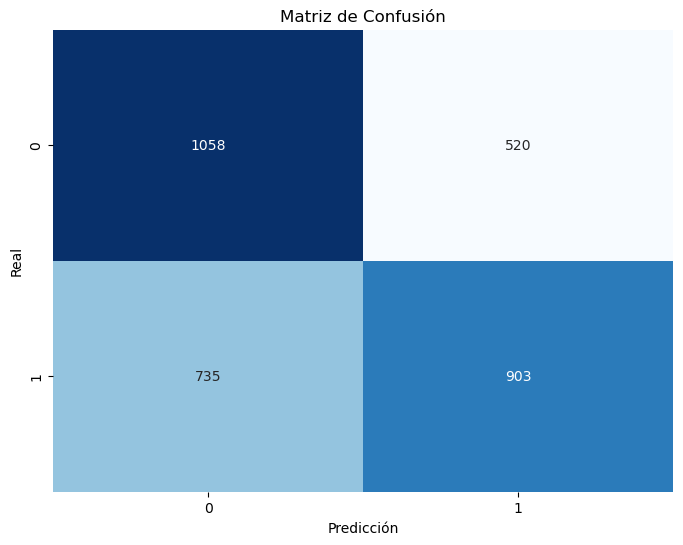

In [47]:
y_pred = model2.predict(X_test)
y_pred
cm = confusion_matrix(y_test,y_pred)
accuracy=accuracy_score(y_test,y_pred)
precision =precision_score(y_test, y_pred,average='micro')
recall =  recall_score(y_test, y_pred,average='micro')
f1 = f1_score(y_test,y_pred,average='micro')
print('Matriz de confusión\n',cm)
print('Accuracy: ',accuracy)
print('Precision: ', precision)
print('recall: ',recall)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=True, yticklabels=True)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()

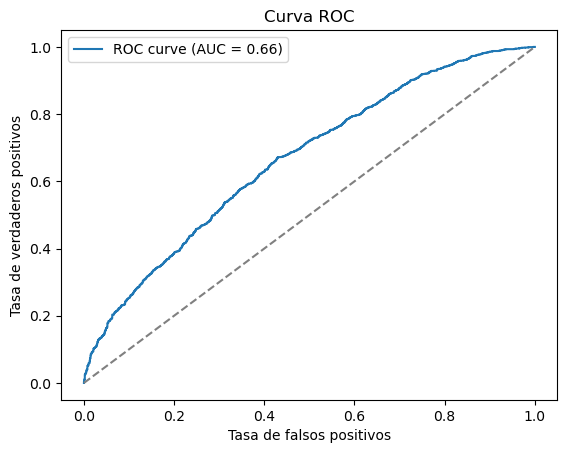

In [48]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Obtener probabilidades (no predicciones duras)
y_scores = model2.predict_proba(X_test)[:, 1]

# Calcular curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

# Graficar
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.title('Curva ROC')
plt.legend()
plt.show()


In [49]:
# Crear un pipeline con el preprocesamiento y el clasificador
model3 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', MLPClassifier(hidden_layer_sizes=(50), max_iter=800, random_state=42, learning_rate='constant', alpha=0.1))
])

# Entrenar el modelo
model3.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['REP_DEP', 'REP_MUNI',
                                                   'VIC_SEXO', 'AGR_SEXO',
                                                   'VIC_GRUPET', 'AGR_GRUPET',
                                                   'VIC_NACIONAL',
                                                   'AGR_NACIONAL', 'VIC_OCUP',
                                                   'AGR_OCUP', 'HEC_DEP',
                                                   'HEC_MUNI', 'HEC_AREA']),
                                                 ('num', StandardScaler(),
                                                  ['VIC_EDAD', 'AGR_EDAD'])])),
                ('classifier',
                 MLPClassifier(alpha=0.1, hidden_layer_sizes=50, max_iter=800,
                               random_state=42))])

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Mejores parámetros encontrados:
{'classifier__alpha': 0.0001, 'classifier__hidden_layer_sizes': (100,), 'classifier__learning_rate_init': 0.001}
Mejor F1 macro en validación cruzada: 0.6339894436739721
Reporte de clasificación:
               precision    recall  f1-score   support

         0.0       0.63      0.64      0.64      1578
         1.0       0.65      0.64      0.64      1638

    accuracy                           0.64      3216
   macro avg       0.64      0.64      0.64      3216
weighted avg       0.64      0.64      0.64      3216

ROC AUC Score: 0.7116715491240206
Matriz de confusión
 [[1058  520]
 [ 735  903]]
Accuracy:  0.6411691542288557
Precision:  0.6411691542288557
recall:  0.6411691542288557
f1score:  0.6411691542288557
Matriz de confusión:
 [[1014  564]
 [ 590 1048]]


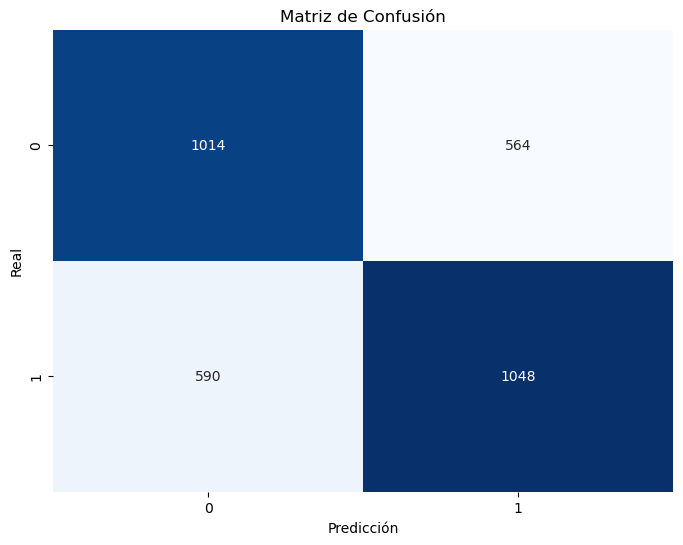

In [50]:
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPClassifier

# Pipeline base con nombre 'classifier' para que GridSearchCV pueda modificarlo
pipeline_nn = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', MLPClassifier(max_iter=1000, random_state=42, early_stopping=True))
])

# Hiperparámetros a probar
param_grid = {
    'classifier__hidden_layer_sizes': [(50,), (64, 32), (100,)],
    'classifier__alpha': [0.0001, 0.001],
    'classifier__learning_rate_init': [0.001, 0.01]
}

# Búsqueda con validación cruzada
grid_search_nn = GridSearchCV(
    estimator=pipeline_nn,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1,
    verbose=2
)

# Entrenar el modelo y buscar los mejores hiperparámetros
grid_search_nn.fit(X_train, y_train)

# Resultados
print("Mejores parámetros encontrados:")
print(grid_search_nn.best_params_)

print("Mejor F1 macro en validación cruzada:", grid_search_nn.best_score_)

# Guardar el mejor modelo
best_nn_model = grid_search_nn.best_estimator_

# Evaluar en test
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = best_nn_model.predict(X_test)
y_proba = best_nn_model.predict_proba(X_test)[:, 1]

print("Reporte de clasificación:\n", classification_report(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_proba))
accuracy=accuracy_score(y_test,y_pred)
precision =precision_score(y_test, y_pred,average='micro')
recall =  recall_score(y_test, y_pred,average='micro')
f1 = f1_score(y_test,y_pred,average='micro')
print('Matriz de confusión\n',cm)
print('Accuracy: ',accuracy)
print('Precision: ', precision)
print('recall: ',recall)
print('f1score: ',f1)

cm = confusion_matrix(y_test,y_pred)
print("Matriz de confusión:\n", cm)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=True, yticklabels=True)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()




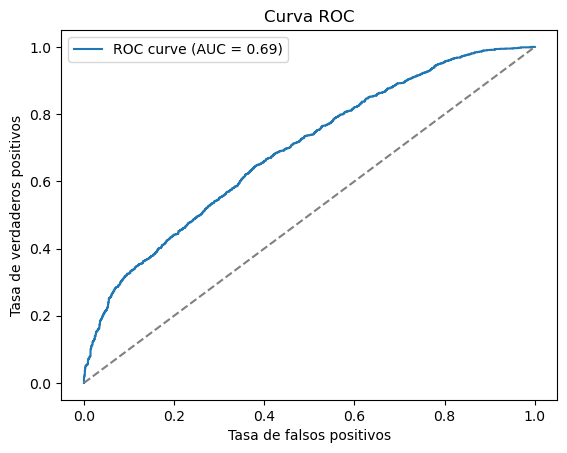

In [51]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Obtener probabilidades (no predicciones duras)
y_scores = model3.predict_proba(X_test)[:, 1]

# Calcular curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

# Graficar
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.title('Curva ROC')
plt.legend()
plt.show()
